# 👹 AN2DL Challenge 2: The Grumpy Doctogres Challenge

## Notebook 01: Exploratory Data Analysis + Preprocessing

This notebook:
1. Loads the dataset,
2. Explores its structure,
3. and prepares the final tensors for model training.

To gain some seconds of life, we will use thread pools for parallel processing where possible.

Despite the GIL (Global Interpreter Lock) limitations in Python, we can still achieve some degree of parallelism for I/O-bound tasks and independent computations.


### 🏴‍☠️ Imports and Paths

In [1]:

import os
import random
from concurrent.futures import ThreadPoolExecutor, Future

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from PIL.ImageFile import ImageFile
from tqdm import tqdm

from internal.persistence_manager import PersistenceManager

DATA_DIR = os.path.join('..', 'data')
TRAIN_PATH = os.path.join(DATA_DIR, "train_data")
LABELS_PATH = os.path.join(DATA_DIR, "train_labels.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_data")

print("The data directory is set to:", DATA_DIR)
print("Train data path:", TRAIN_PATH)
print("Labels data path:", LABELS_PATH)
print("Test data path:", TEST_PATH)

# Load labels
labels_df = pd.read_csv(LABELS_PATH)

# Store in dictionary: sample_index -> label
label_map = dict(zip(labels_df["sample_index"], labels_df["label"]))

def build_df(img_dir: str, is_train: bool = True) -> pd.DataFrame:
    """
    Builds a DataFrame from images in `img_dir`.
    - Scans `img_dir` for PNG images (excluding files with 'mask' in the name).
    - For each image, checks mask existence and pulls label from the global `label_map` when `is_train`.
    """
    rows: list = []

    for file_name in sorted(os.listdir(img_dir)):
        if file_name.endswith(".png") and "mask" not in file_name:
            # extract index
            sample_index: str = file_name.replace(".png", "")

            # extract number only
            index: str = sample_index.replace("img_", "")

            # corresponding mask path
            mask_path: str = os.path.join(img_dir, f"mask_{index}.png")

            # collect row
            rows.append({
                "sample_index": sample_index,
                "image_path": os.path.join(img_dir, file_name),
                "mask_path": mask_path if os.path.exists(mask_path) else None,
                "label": label_map.get(file_name) if is_train else None
            })

    return pd.DataFrame(rows)

with (ThreadPoolExecutor() as executor):
    future_train: Future[pd.DataFrame] = executor.submit(build_df, TRAIN_PATH, True)
    future_test: Future[pd.DataFrame]  = executor.submit(build_df, TEST_PATH,  False)

    train_df: pd.DataFrame = future_train.result()
    test_df: pd.DataFrame  = future_test.result()

print(train_df.head())
print(test_df.head())


The data directory is set to: ../data
Train data path: ../data/train_data
Labels data path: ../data/train_labels.csv
Test data path: ../data/test_data
  sample_index                       image_path  \
0     img_0000  ../data/train_data/img_0000.png   
1     img_0001  ../data/train_data/img_0001.png   
2     img_0002  ../data/train_data/img_0002.png   
3     img_0003  ../data/train_data/img_0003.png   
4     img_0004  ../data/train_data/img_0004.png   

                          mask_path            label  
0  ../data/train_data/mask_0000.png  Triple negative  
1  ../data/train_data/mask_0001.png        Luminal A  
2  ../data/train_data/mask_0002.png        Luminal A  
3  ../data/train_data/mask_0003.png        Luminal B  
4  ../data/train_data/mask_0004.png          HER2(+)  
  sample_index                      image_path  \
0     img_0000  ../data/test_data/img_0000.png   
1     img_0001  ../data/test_data/img_0001.png   
2     img_0002  ../data/test_data/img_0002.png   
3     img_00

In [2]:
train_df['label'].value_counts()
train_df['label'].value_counts(normalize=True)

label
Luminal B          0.315156
Luminal A          0.293201
HER2(+)            0.281161
Triple negative    0.110482
Name: proportion, dtype: float64

In [3]:
train_df['mask_missing'] = train_df['mask_path'].isnull()
train_df['mask_missing'].value_counts()

mask_missing
False    1412
Name: count, dtype: int64

In [4]:
sizes: list[tuple[int, int]] = []
mask_pixels: list[int] = []
bbox_areas: list[np.int64] = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    # Read image size
    img: ImageFile = Image.open(row["image_path"])
    # Get width and height
    width, height = img.size
    # Store size
    sizes.append((width, height))

    # Open mask image if exists
    mask = Image.open(row["mask_path"]) if row["mask_path"] else None

    # Process mask if exists
    if not mask:
        continue

    # Convert mask to numpy array
    m = np.array(mask)
    # Find non-zero mask pixels
    pos: np.ndarray = np.argwhere(m > 0)

    # Compute bounding box area
    if len(pos) > 0: # If there are mask pixels
        y_min, x_min = pos.min(axis=0)
        y_max, x_max = pos.max(axis=0)
        # The area of the bounding box
        bbox_area: np.int64 = (x_max - x_min) * (y_max - y_min)
        bbox_areas.append(bbox_area)
        mask_pixels.append(pos.shape[0])
    else:
        mask_pixels.append(0)
        bbox_areas.append(np.int64(0))

train_df["width"] = [s[0] for s in sizes]
train_df["height"] = [s[1] for s in sizes]
train_df["mask_pixels"] = mask_pixels
train_df["bbox_area"] = bbox_areas

train_df.head()

100%|██████████| 1412/1412 [00:07<00:00, 200.67it/s]


,sample_index,image_path,mask_path,label,mask_missing,width,height,mask_pixels,bbox_area
0,img_0000,../data/train_data/img_0000.png,../data/train_data/mask_0000.png,Triple negative,False,1024,1097,12798,522120
1,img_0001,../data/train_data/img_0001.png,../data/train_data/mask_0001.png,Luminal A,False,1024,1221,8859,305256
2,img_0002,../data/train_data/img_0002.png,../data/train_data/mask_0002.png,Luminal A,False,1024,1203,5306,35478
3,img_0003,../data/train_data/img_0003.png,../data/train_data/mask_0003.png,Luminal B,False,1024,1053,30986,506174
4,img_0004,../data/train_data/img_0004.png,../data/train_data/mask_0004.png,HER2(+),False,1024,1404,76667,260352


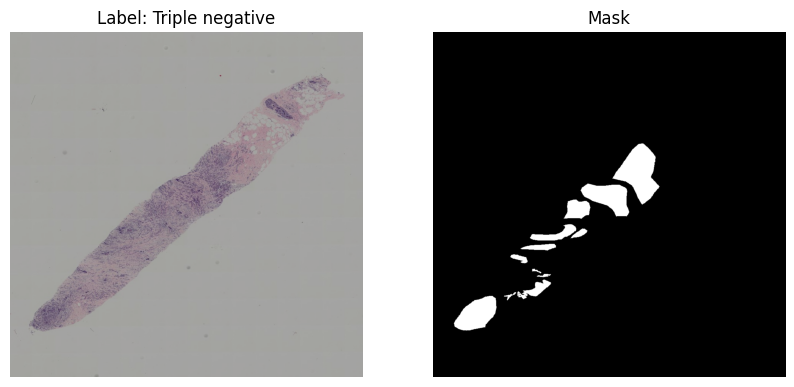

In [5]:
def show_sample(idx: int | None = None):
    if idx is None:
        idx = random.randint(0, len(train_df)-1)

    _row: pd.Series = train_df.iloc[idx]

    _img: np.ndarray = np.array(Image.open(_row["image_path"]))
    _mask: np.ndarray = np.array(Image.open(_row["mask_path"]))

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title(f"Label: {_row['label']}")
    plt.imshow(_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(_mask, cmap="gray")
    plt.axis("off")

    plt.show()

show_sample()

In [6]:
train_df[['width','height']].describe()

,width,height
count,1412.000000,1412.000000
mean,1252.313031,1341.359065
std,446.147652,509.641453
min,1024.000000,1024.000000
25%,1024.000000,1024.000000
50%,1024.000000,1097.500000
75%,1294.000000,1468.250000
max,3970.000000,4233.000000


In [7]:
train_df['mask_pixels'].describe()

count      1412.000000
mean      34219.893768
std       42038.650096
min        1727.000000
25%       10401.500000
50%       19104.500000
75%       38725.000000
max      355190.000000
Name: mask_pixels, dtype: float64

In [8]:
train_df['bbox_area'].describe()

count    1.412000e+03
mean     3.865837e+05
std      2.579475e+05
min      1.248300e+04
25%      1.915610e+05
50%      3.438030e+05
75%      5.426298e+05
max      1.662888e+06
Name: bbox_area, dtype: float64

In [9]:
PersistenceManager.save_train_and_test_df({
    "train_df": train_df,
    "test_df": test_df
})

Arrays and scalers saved successfully to: /home/andre/university/AN2DL-Challenge-2/notebooks/processed/train_and_test_df.joblib
